# 07 — CF/attribute hygiene and the browse image

**Fix.** Product attributes and coordinate variables follow CF; the browse PNG fits the
size limit, uses robust colour limits, does not smear zeros into the data edges and no
longer modifies its input.

**Where the defects were** (commit `d0901b3`).
* `src/cal_disp/product/output/_main.py` ~l.87-100 — root attributes `"30 meteres"`,
  `"mision_name"`, `reference_document`/`history` = `"TBD"`, `temporal_resolution: "12 days"`
  hard-coded, software version duplicated in a root attribute and in `/metadata`.
* `_main.py` ~l.48-49 and `_auxiliary.py` ~l.58 — hand-set `coordinates` attributes
  (`"y x"` on `(time, y, x)` variables in `/auxiliary`); `x`/`y` without
  `standard_name`/`units`/`long_name` and written with a `_FillValue`.
* `src/cal_disp/browse_image.py` ~l.22 — `max(...)` of the two scale ratios where `min(...)`
  is needed, so the PNG exceeded `max_dim_allowed=2048`; fixed `vmin/vmax = ±0.10 m`;
  cubic `ndimage.zoom` after NaN→0; the input array was modified in place.

**What is demonstrated.** The golden dataset on disk is produced by the *fixed* code, so
it is the "after". The "before" state is reconstructed from git history (`d0901b3`): the
golden arrays written with the pre-fix writer, and the browse image rendered with the
pre-fix `browse_image.py`. Shown: the root attributes before/after, a local CF checklist
on both products, and the old and new browse PNG side by side.

In [1]:
import os
from pathlib import Path
REPO = Path.cwd().resolve().parents[1]          # docs/notebooks -> repo root
GOLDEN = Path(os.environ.get("CAL_DISP_GOLDEN_DIR", REPO / "test_golden"))
SCRATCH = Path(os.environ.get("TMPDIR", REPO / "tmp")) / "cal_disp_notebooks"; SCRATCH.mkdir(parents=True, exist_ok=True)

In [2]:
import re
from datetime import datetime

import h5py
import numpy as np
import pandas as pd
import xarray as xr
from PIL import Image
from scipy import ndimage

import cal_disp
from cal_disp.browse_image import DEFAULT_CMAP, _resize_to_max_pixel_dim, make_browse_image_from_arr, symmetric_limits

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 250)
DISP_NC = next((GOLDEN / "input_data" / "disp").glob("OPERA_L3_DISP-S1_*.nc"))
GOLDEN_NC = next((GOLDEN / "golden_output").glob("OPERA_L4_DISP-CAL-S1_*.nc"))
GOLDEN_PNG = GOLDEN_NC.with_suffix(".png")
print("cal_disp from:", Path(cal_disp.__path__[0]).relative_to(REPO) if Path(cal_disp.__path__[0]).is_relative_to(REPO) else cal_disp.__path__[0])
print("DISP input   :", DISP_NC.name)
print("golden output:", GOLDEN_NC.name)

cal_disp from: src/cal_disp
DISP input   : OPERA_L3_DISP-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20251027T005420Z.nc
golden output: OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc


## The fixed product ("after"): the golden when written by the fixed code, else a full-frame run

In [3]:
import subprocess
import sys
import time


def is_fixed_product(path: Path) -> bool:
    """Was `path` written by the fixed writer (Fix 1, 3 and 4 markers)?"""
    with h5py.File(path) as f:
        return (
            f["calibration"].chunks is not None
            and "GeoTransform" in f["spatial_ref"].attrs
            and "mission_name" in f.attrs
        )


def fixed_product(run_dir: Path = SCRATCH / "fixed_run") -> Path:
    """Product of a full-frame `cal-disp run` of the current code on the golden inputs.

    Only needed when the golden dataset predates the fixes; reused from
    scratch if present (the run takes a few minutes and ~18 GB RAM).
    """
    out_dir = run_dir / "output"
    found = sorted(out_dir.glob("OPERA_L4_DISP-CAL-S1_*.nc"))
    if found:
        return found[-1]
    inp = GOLDEN / "input_data"
    one = lambda d, pat: str(sorted((inp / d).glob(pat))[0])
    tropo = sorted(str(p) for p in (inp / "tropo").glob("OPERA_L4_TROPO-ZENITH_*.nc"))
    config = run_dir / "work" / "runconfig.yaml"  # `cal-disp config` writes it into --work-dir
    run_dir.mkdir(parents=True, exist_ok=True)
    cli = [sys.executable, "-c", "from cal_disp.cli import cli_app; cli_app()"]
    subprocess.run(
        [*cli, "config",
         "-d", one("disp", "OPERA_L3_DISP-S1_*.nc"),
         "-ul", one("gnss", "grid_latlon_lookup_v*.txt"), "-ud", str(inp / "gnss"),
         "-uv", "0.3", "-ut", "constant",
         "--los-file", one("static_input", "*line_of_sight_enu.tif"),
         "--dem-file", one("static_input", "*_dem.tif"),
         "--ref-tropo-files", tropo[0], "--sec-tropo-files", tropo[1],
         "-a", str(GOLDEN / "configs" / "algorithm_parameters.yaml"),
         "--frame-id", "8882",
         "-o", str(out_dir), "--work-dir", str(run_dir / "work"), "-c", str(config)],
        check=True, capture_output=True,
    )
    t0 = time.time()
    with (run_dir / "run.log").open("w") as log:
        subprocess.run([*cli, "run", str(config)], check=True, stdout=log, stderr=log)
    print(f"cal-disp run finished in {time.time() - t0:.0f} s")
    return sorted(out_dir.glob("OPERA_L4_DISP-CAL-S1_*.nc"))[-1]


if is_fixed_product(GOLDEN_NC):
    FIXED_NC = GOLDEN_NC
    print("fixed product: the golden dataset (built by the fixed code)")
else:
    FIXED_NC = fixed_product()
    print("fixed product: full-frame run of the current code,", FIXED_NC.relative_to(SCRATCH))

fixed product: the golden dataset (built by the fixed code)


## The pre-fix product ("before")

The golden arrays written with `build_main_dataset` / `build_auxiliary_dataset` of commit
`d0901b3`, imported from git history (reused from scratch if already written).

In [4]:
import subprocess
import types

OLD_COMMIT = "d0901b3"  # gamma-release before the product fixes (d0548bf..79ab02a)


def old_module(rel_path: str) -> types.ModuleType:
    """Import one module of the pre-fix code straight from git history."""
    src = subprocess.check_output(["git", "-C", str(REPO), "show", f"{OLD_COMMIT}:{rel_path}"], text=True)
    mod = types.ModuleType("old_" + Path(rel_path).stem.strip("_"))
    mod.__file__ = f"{OLD_COMMIT}:{rel_path}"
    exec(compile(src, mod.__file__, "exec"), mod.__dict__)
    return mod

In [5]:
def golden_arrays():
    """Coordinates, layers and DISP spatial_ref of the golden product."""
    with xr.open_dataset(GOLDEN_NC, engine="h5netcdf") as ds:
        coords = {"time": ds.time.values, "y": ds.y.values, "x": ds.x.values}
        layers = {k: ds[k].values for k in ("calibration", "calibration_std")}
        extra = {k: ds.attrs[k] for k in ("gnss_reference_epoch", "auxiliary_model_3d_resolution", "calibration_resolution") if k in ds.attrs}
    with xr.open_dataset(GOLDEN_NC, group="auxiliary", engine="h5netcdf") as ds:
        aux_coords = {"time": ds.time.values, "y": ds.y.values, "x": ds.x.values}
        aux = {k: ds[k].values for k in ("north_south", "east_west", "up_down")}
    with xr.open_dataset(DISP_NC, engine="h5netcdf") as ds:
        spatial_ref = ds["spatial_ref"].load()
    return coords, layers, extra, aux_coords, aux, spatial_ref


def before_product(out_dir: Path = SCRATCH / "before_product") -> Path:
    """The golden arrays written by the pre-fix writer (reused from scratch if present).

    Uses build_main_dataset/build_auxiliary_dataset of commit d0901b3 and, as
    that code did, to_netcdf without any encoding.
    """
    path = out_dir / GOLDEN_NC.name
    if path.exists():
        return path
    out_dir.mkdir(parents=True, exist_ok=True)
    old_main = old_module("src/cal_disp/product/output/_main.py")
    old_aux = old_module("src/cal_disp/product/output/_auxiliary.py")
    coords, layers, extra, aux_coords, aux, spatial_ref = golden_arrays()
    dims = ["time", "y", "x"]
    ds_main = old_main.build_main_dataset(
        calibration=xr.DataArray(layers["calibration"], coords=coords, dims=dims),
        calibration_std=xr.DataArray(layers["calibration_std"], coords=coords, dims=dims),
        spatial_ref=spatial_ref,
        sensor="S1",
        metadata=extra,
    )
    ds_aux = old_aux.build_auxiliary_dataset(
        model_3d={k: xr.DataArray(v, coords=aux_coords, dims=dims) for k, v in aux.items()},
        model_3d_std=None,
        spatial_ref=spatial_ref,
    )
    tmp = path.with_name(path.name + ".partial")
    ds_main.to_netcdf(tmp, engine="h5netcdf")
    ds_aux.to_netcdf(tmp, mode="a", group="auxiliary", engine="h5netcdf")
    tmp.rename(path)
    return path


BEFORE_NC = before_product()
print("before (pre-fix writer):", BEFORE_NC.relative_to(SCRATCH), f"{BEFORE_NC.stat().st_size / 1e6:.1f} MB")

before (pre-fix writer): before_product/OPERA_L4_DISP-CAL-S1_IW_F08882_VV_20220111T002651Z_20220722T002657Z_v1.0_20260930T213458Z.nc 585.7 MB


## 1. Root attributes before and after

In [6]:
def root_attrs(path):
    with h5py.File(path) as f:
        return {k: (v if isinstance(v, str) else str(v)) for k, v in f.attrs.items() if not k.startswith("_")}


attrs = pd.DataFrame({"before (pre-fix writer)": root_attrs(BEFORE_NC), "fixed (after)": root_attrs(FIXED_NC)}).fillna("(absent)")
changed = attrs[attrs["before (pre-fix writer)"] != attrs["fixed (after)"]]
print(f"{len(attrs)} root attributes in total, {len(changed)} differ:")
assert {"mision_name", "mission_name", "spatial_resolution", "temporal_resolution", "reference_document", "history"} <= set(changed.index)
changed

21 root attributes in total, 8 differ:


,before (pre-fix writer),fixed (after)
spatial_resolution,30 meteres,30 meters
temporal_resolution,12 days,192 days
mision_name,OPERA,(absent)
software,cal_disp,(absent)
software_version,0.2.post1.dev66+g8a746c8a8,(absent)
reference_document,TBD,https://opera-adt.github.io/cal-disp/
history,TBD,2026-09-30T21:34:59Z: created by cal_disp 0.2.post1.dev62+g4117f9341.d20260930
mission_name,(absent),OPERA


`software` / `software_version` are gone from the root on purpose: the version is stored
once, in `/metadata/cal_disp_software_version`, and named in `history`.

In [7]:
with h5py.File(FIXED_NC) as f:
    print("root has software_version:", "software_version" in f.attrs)
    print("/metadata/cal_disp_software_version:", f["metadata/cal_disp_software_version"][()].decode())
    print("history:", f.attrs["history"])

root has software_version: False
/metadata/cal_disp_software_version: 0.2.post1.dev62+g4117f9341.d20260930
history: 2026-09-30T21:34:59Z: created by cal_disp 0.2.post1.dev62+g4117f9341.d20260930


## 2. CF checklist

A small local check of the points a CF checker would flag in this product. It reads the
raw HDF5 attributes (not xarray's decoded view) of the root and `/auxiliary` groups.

In [8]:
def cf_checklist(path):
    """{check: (passed, detail)} for the root and /auxiliary groups of a DISP-CAL product."""
    res = {}
    with h5py.File(path) as f:
        groups = {"/": f, "/auxiliary/": f["auxiliary"]}
        coords = {g + n: grp[n] for g, grp in groups.items() for n in ("x", "y", "time") if n in grp}
        rasters = {g + n: d for g, grp in groups.items() for n, d in grp.items()
                   if isinstance(d, h5py.Dataset) and d.ndim >= 2}

        res["Conventions global attribute"] = ("Conventions" in f.attrs, str(f.attrs.get("Conventions")))

        bad = [p for p, d in coords.items() if "_FillValue" in d.attrs]
        res["coordinate variables have no _FillValue"] = (not bad, ", ".join(bad) or f"{len(coords)} coordinate variables")

        bad = [p for p, d in coords.items() if "standard_name" not in d.attrs or "units" not in d.attrs]
        res["coordinates have standard_name and units"] = (not bad, ", ".join(bad) or "x, y: m; time: CF time units")

        bad = [p for p, d in rasters.items() if "units" not in d.attrs]
        res["every raster variable has units"] = (not bad, ", ".join(bad) or f"{len(rasters)} raster variables")

        bad = []
        for p, d in rasters.items():
            name = d.attrs.get("grid_mapping")
            target = d.parent[name] if name and name in d.parent else None
            need = {"grid_mapping_name", "crs_wkt", "GeoTransform"}
            if target is None:
                bad.append(f"{p}: no grid_mapping variable")
            elif need - set(target.attrs):
                bad.append(f"{p}: spatial_ref lacks {sorted(need - set(target.attrs))}")
        res["grid_mapping resolves (grid_mapping_name, crs_wkt, GeoTransform)"] = (not bad, "; ".join(bad[:2]) or "spatial_ref in each group")

        # CF 5: 'coordinates' lists auxiliary coordinate variables, not the dimensions
        bad = []
        for p, d in rasters.items():
            if "coordinates" in d.attrs:
                dims = [d.dims[i][0].name.split("/")[-1] for i in range(d.ndim)]
                bad.append(f"{p}: coordinates='{d.attrs['coordinates']}' on dims {tuple(dims)}")
        res["no hand-set 'coordinates' attribute"] = (not bad, "; ".join(bad[:2]) + (" ..." if len(bad) > 2 else "") or "none present")

        known = {"mission_name", "spatial_resolution", "temporal_resolution", "reference_document", "history"}
        bad = [f"{k}='{v}'" for k, v in f.attrs.items() if isinstance(v, str) and (v == "TBD" or "meteres" in v)]
        bad += [k for k in f.attrs if k == "mision_name"] + [f"missing {k}" for k in sorted(known - set(f.attrs))]
        res["global attributes: no placeholders or misspellings"] = (not bad, ", ".join(bad) or "ok")

        ref, sec = (datetime.strptime(s, "%Y%m%dT%H%M%SZ") for s in re.findall(r"\d{8}T\d{6}Z", Path(path).name)[:2])
        want = f"{(sec - ref).days} days"
        got = f.attrs.get("temporal_resolution")
        res["temporal_resolution equals the pair's baseline"] = (got == want, f"'{got}' (pair: {want})")
    return res


def verdicts(path):
    return {k: ("PASS" if ok else "FAIL") + f" - {detail}" for k, (ok, detail) in cf_checklist(path).items()}


checklist = pd.DataFrame({"before (pre-fix writer)": verdicts(BEFORE_NC), "fixed (after)": verdicts(FIXED_NC)})
n_fail_before = checklist["before (pre-fix writer)"].str.startswith("FAIL").sum()
n_fail_after = checklist["fixed (after)"].str.startswith("FAIL").sum()
print(f"failed checks: {n_fail_before} of {len(checklist)} before, {n_fail_after} after")
assert n_fail_after == 0 and n_fail_before >= 5
checklist

failed checks: 6 of 8 before, 0 after


,before (pre-fix writer),fixed (after)
Conventions global attribute,PASS - CF-1.8,PASS - CF-1.8
coordinate variables have no _FillValue,"FAIL - /x, /y, /auxiliary/x, /auxiliary/y",PASS - 6 coordinate variables
coordinates have standard_name and units,"FAIL - /x, /y, /time, /auxiliary/x, /auxiliary/y, /auxiliary/time","PASS - x, y: m; time: CF time units"
every raster variable has units,PASS - 5 raster variables,PASS - 5 raster variables
"grid_mapping resolves (grid_mapping_name, crs_wkt, GeoTransform)",FAIL - /calibration: spatial_ref lacks ['GeoTransform']; /calibration_std: spatial_ref...,PASS - spatial_ref in each group
no hand-set 'coordinates' attribute,"FAIL - /calibration: coordinates='time y x' on dims ('time', 'y', 'x'); /calibration_s...",PASS - none present
global attributes: no placeholders or misspellings,"FAIL - spatial_resolution='30 meteres', reference_document='TBD', history='TBD', misio...",PASS - ok
temporal_resolution equals the pair's baseline,FAIL - '12 days' (pair: 192 days),PASS - '192 days' (pair: 192 days)


Coordinate variables of the fixed product (raw HDF5 attributes):

In [9]:
with h5py.File(FIXED_NC) as f:
    rows = {p: {k: v for k, v in f[p].attrs.items() if k in ("standard_name", "long_name", "units", "calendar", "_FillValue")}
            for p in ("x", "y", "time", "auxiliary/x", "auxiliary/y")}
pd.DataFrame(rows).T.fillna("-")

,standard_name,long_name,units,calendar
x,projection_x_coordinate,x coordinate of projection,m,-
y,projection_y_coordinate,y coordinate of projection,m,-
time,time,Time corresponding to beginning of secondary acquisition,days since 2022-07-22 00:26:57.253009984,proleptic_gregorian
auxiliary/x,projection_x_coordinate,x coordinate of projection,m,-
auxiliary/y,projection_y_coordinate,y coordinate of projection,m,-


## 3. Browse image

Both images are rendered here from the *same* calibration layer (the fixed product's):
the old one with `browse_image.py` of commit `d0901b3`, imported from git history, the new
one with the current module. The PNG delivered with the golden product (current code) is
listed for reference.

In [10]:
old_browse = old_module("src/cal_disp/browse_image.py")

with h5py.File(FIXED_NC) as f:
    cal = f["calibration"][0]
valid = np.isfinite(cal)
print(f"calibration: {cal.shape[0]} x {cal.shape[1]}, {valid.mean():.1%} valid, "
      f"range {np.nanmin(cal):+.3f} .. {np.nanmax(cal):+.3f} m")

out_dir = SCRATCH / "07_cf_attrs_and_browse"
out_dir.mkdir(exist_ok=True)
old_png, new_png = out_dir / "browse_old.png", out_dir / "browse_fixed.png"

old_browse.make_browse_image_from_nc(old_png, FIXED_NC)  # pre-fix code, default arguments
before_bytes = cal.tobytes()
limits = make_browse_image_from_arr(new_png, cal)  # current code
assert cal.tobytes() == before_bytes

# the resize step alone, old and new, on the same array
probe = cal.copy()
resized = {"old": old_browse._resize_to_max_pixel_dim(probe, 2048), "new": _resize_to_max_pixel_dim(cal, 2048)}
print("input array modified by the resize:  old code:", probe.tobytes() != before_bytes, "| new code:", cal.tobytes() != before_bytes)
assert probe.tobytes() != before_bytes

pngs = {f"old (browse_image.py at {OLD_COMMIT})": old_png, "new (current browse_image.py)": new_png,
        "PNG delivered with the golden product": GOLDEN_PNG}
rows = {}
for label, p in pngs.items():
    with Image.open(p) as im:
        rows[label] = {"width x height": f"{im.width} x {im.height}", "largest dimension": max(im.size),
                       "within 2048": max(im.size) <= 2048, "file MB": round(p.stat().st_size / 1e6, 2)}
sizes = pd.DataFrame(rows).T
assert not sizes["within 2048"].iloc[0] and sizes["within 2048"].iloc[1]
sizes

calibration: 7733 x 9464, 66.1% valid, range -0.097 .. +0.145 m


input array modified by the resize:  old code: True | new code: False


,width x height,largest dimension,within 2048,file MB
old (browse_image.py at d0901b3),2506 x 2048,2506,False,2.77
new (current browse_image.py),2048 x 1673,2048,True,1.94
PNG delivered with the golden product,2048 x 1673,2048,True,1.94


### Colour limits

In [11]:
absval = np.abs(cal[valid])
colour = pd.DataFrame({
    "old": {"vmin / vmax (m)": "-0.100 / +0.100 (fixed)", "valid pixels beyond the limits": f"{(absval > 0.10).mean():.1%}"},
    "new": {"vmin / vmax (m)": f"{limits[0]:+.3f} / {limits[1]:+.3f} (98th percentile of |value|, symmetric)",
            "valid pixels beyond the limits": f"{(absval > limits[1]).mean():.1%}"},
}).T
assert limits[0] == -limits[1] and limits == symmetric_limits(cal)
colour

,vmin / vmax (m),valid pixels beyond the limits
old,-0.100 / +0.100 (fixed),6.4%
new,"-0.131 / +0.131 (98th percentile of |value|, symmetric)",2.0%


### Edge bleeding

The old resize set NaN to 0 and ran a cubic `ndimage.zoom`, so valid pixels next to the
NaN boundary were pulled towards 0 (and could overshoot). The error of each resized image
is measured against the full-resolution value at the same location, for valid pixels
within 2 pixels of the NaN boundary and for the rest. The interior error is the ordinary
cost of downsampling a rough field; without bleeding, the edge error should be of the
same order.

In [12]:
def sampled_truth(arr, shape):
    """Full-resolution values at the locations of the resized pixels."""
    rows = np.round(np.arange(shape[0]) * (arr.shape[0] - 1) / (shape[0] - 1)).astype(int)
    cols = np.round(np.arange(shape[1]) * (arr.shape[1] - 1) / (shape[1] - 1)).astype(int)
    return arr[np.ix_(rows, cols)]


rows = {}
for label, img in resized.items():
    truth = sampled_truth(cal, img.shape)
    both = np.isfinite(img) & np.isfinite(truth)
    edge = both & ndimage.binary_dilation(~both, iterations=2)
    err = np.abs(img - truth) * 1e3  # mm
    rows[label] = {
        "resized shape (rows x cols)": f"{img.shape[0]} x {img.shape[1]}",
        "edge pixels": int(edge.sum()),
        "edge error mm (median)": round(float(np.median(err[edge])), 2),
        "edge error mm (99th pct)": round(float(np.percentile(err[edge], 99)), 2),
        "edge error mm (max)": round(float(err[edge].max()), 2),
        "interior error mm (99th pct)": round(float(np.percentile(err[both & ~edge], 99)), 2),
    }
edge_table = pd.DataFrame(rows).T
assert edge_table.loc["new", "edge error mm (99th pct)"] < edge_table.loc["old", "edge error mm (99th pct)"]
ratio = {k: edge_table.loc[k, "edge error mm (99th pct)"] / edge_table.loc[k, "interior error mm (99th pct)"] for k in resized}
print(f"edge / interior error (99th pct): old {ratio['old']:.1f}x, new {ratio['new']:.1f}x")
edge_table

edge / interior error (99th pct): old 6.8x, new 1.2x


,resized shape (rows x cols),edge pixels,edge error mm (median),edge error mm (99th pct),edge error mm (max),interior error mm (99th pct)
old,2048 x 2506,15286,0.19,39.75,86.52,5.85
new,1673 x 2048,12488,0.01,7.01,12.42,5.85


### Old and new PNG side by side

Top: the two PNGs — the old limits clip everything beyond ±0.10 m. Bottom: the boxed area
of the two *resized arrays*, both drawn with the new colour limits so that only the
resampling differs. The zero-bleeding of the old resize is confined to the outermost one
or two pixels of the data edge, so it is hardly visible at this scale; the table above
quantifies it.

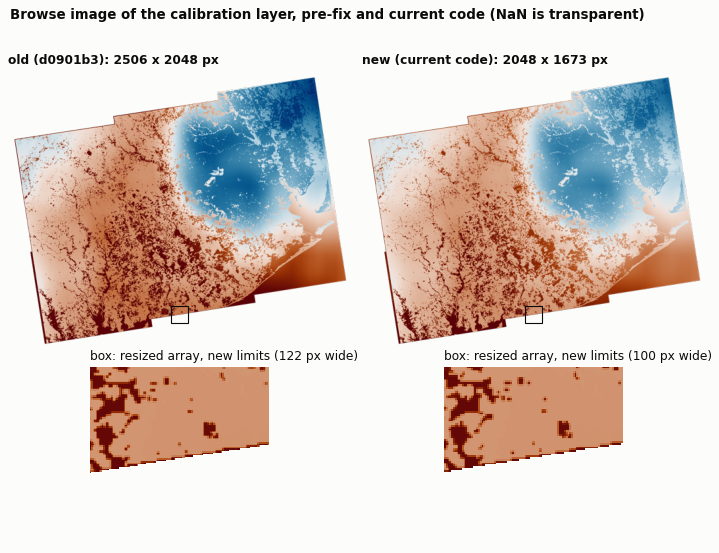

In [13]:
import matplotlib.pyplot as plt

SURFACE, INK, MUTED, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 80, "savefig.dpi": 80, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#d9d8d2", "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})

def load(path, max_side=None):
    with Image.open(path) as im:
        im = im.convert("RGBA")
        if max_side:
            im.thumbnail((max_side, max_side))
        return np.asarray(im)


# A box on the NaN boundary, at the same relative position in both images
new_img = resized["new"]
boundary = np.isfinite(new_img) & ndimage.binary_dilation(np.isnan(new_img))
rr, cc = np.nonzero(boundary)
pick = np.argmin(np.abs(rr - new_img.shape[0] * 0.55) + np.abs(cc - new_img.shape[1] * 0.5))
fy, fx = rr[pick] / new_img.shape[0], cc[pick] / new_img.shape[1]

fig, axes = plt.subplots(2, 2, figsize=(9, 6.9), gridspec_kw={"height_ratios": [1, 0.62]})
panels = [("old", f"old ({OLD_COMMIT})", old_png), ("new", "new (current code)", new_png)]
for col, (key, label, path) in enumerate(panels):
    with Image.open(path) as im:
        w, h = im.size
    axes[0, col].imshow(load(path, 520))
    axes[0, col].set_title(f"{label}: {w} x {h} px")
    img = resized[key]
    assert img.shape == (h, w), (img.shape, (h, w))  # the PNG is the resized array
    half = int(0.03 * h)
    r0, c0 = int(fy * h), int(fx * w)
    crop = img[max(r0 - half, 0) : r0 + half, max(c0 - half, 0) : c0 + half]
    axes[1, col].imshow(crop, cmap=DEFAULT_CMAP, vmin=limits[0], vmax=limits[1], interpolation="nearest")
    axes[1, col].set_title(f"box: resized array, new limits ({crop.shape[1]} px wide)", fontweight="normal")
    # outline of the crop in the overview
    s = 520 / max(w, h)
    axes[0, col].add_patch(plt.Rectangle(((c0 - half) * s, (r0 - half) * s), 2 * half * s, 2 * half * s,
                                         fill=False, edgecolor=INK, linewidth=1))
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
fig.suptitle("Browse image of the calibration layer, pre-fix and current code (NaN is transparent)", x=0.02, y=0.995, ha="left", fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## Summary

* Root attributes: the typos, `TBD` placeholders and the hard-coded `12 days` are gone
  (`temporal_resolution` is the pair's baseline); the software version is stored once, in
  `/metadata`.
* CF checklist: the failures of the pre-fix product (`_FillValue` on coordinates,
  coordinates without `standard_name`/`units`, hand-set `coordinates` attributes,
  `spatial_ref` without `GeoTransform`, placeholder attributes, wrong temporal resolution)
  all pass on the fixed product.
* Browse PNG: the largest dimension is 2048 px (2506 with the pre-fix code); colour limits
  follow the data instead of clipping at ±0.10 m; the edge-error table shows the
  zero-bleeding of the old resize (edge error several times the interior error), while the
  new resize keeps the edge error at the level of the interior one; the input array is
  left untouched.